## Model

In [1]:
import numpy as np

class CustomLinearSVM:
    def __init__(self, learning_rate=0.001, lambda_param=0.01, n_iters=1000):

        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters        
        self.w = None
        self.b = None

    def fit(self, X, y):
        
        n_samples, n_features = X.shape
        
        self.w = np.zeros(n_features)
        self.b = 0.0
        
        y_mirrored = np.where(y <= 0, -1, 1)

        for epoch in range(self.n_iters):
            
            for idx, x_i in enumerate(X):
                
                y_i = y_mirrored[idx]
                f_i= np.dot((self.w).T, x_i)+self.b

                if f_i * y_i <1:
                    self.w=self.w-self.lr*(self.lambda_param*self.w - y_i*x_i)
                    self.b = self.b + self.lr * y_i
                
                else:
                    self.w=self.w-self.lr*self.lambda_param*self.w 

                
              

    def predict(self, X):
       linear_output = np.dot(X, self.w) + self.b
       prediction = np.where(linear_output >= 0, 1, 0)
       return prediction
       


class OneVsRestSVM:
    def __init__(self, n_classes=10, learning_rate=0.001, lambda_param=0.01, n_iters=50):
        self.n_classes = n_classes
        self.lr = learning_rate
        self.lambda_param = lambda_param
        self.n_iters = n_iters
        self.models = []

    def fit(self, X, y):
        for i in range(self.n_classes):
            print(f"    Training binary model for Class {i} vs Rest...")
            
            y_binary = np.where(y == i, 1, 0)
            
            binary_model = CustomLinearSVM(
                learning_rate=self.lr, 
                lambda_param=self.lambda_param, 
                n_iters=self.n_iters
            )
            binary_model.fit(X, y_binary)
            self.models.append(binary_model)

    def predict(self, X):
        n_samples = X.shape[0]
        scores = np.zeros((n_samples, self.n_classes))
        
        for i, model in enumerate(self.models):
            raw_value = np.dot(X, model.w) + model.b
            scores[:, i] = raw_value
        
        winning_classes = np.argmax(scores, axis=1)
        return winning_classes

## Training
#### HOG

In [2]:
import time

from preprocessing2 import preprocess
from sklearn.metrics import classification_report, confusion_matrix

X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="hog", n_pca=50)

# ==========================================
# 4. TRAIN AND EVALUATE
# ==========================================
print("\nInitializing Custom 10-Class SVM (OvR)...")
ovr_svm = OneVsRestSVM(n_classes=10, learning_rate=0.001, lambda_param=0.01, n_iters=50)

print("Training all 10 models... (This might take a few minutes in Python)")
start_time = time.time()
ovr_svm.fit(X_train, y_train)
print(f"Full 10-Class Training completed in {(time.time() - start_time):.2f} seconds.")

print("\nEvaluating on Validation Data...")
val_preds = ovr_svm.predict(X_val)

print("\n" + "="*50)
print("  10-CLASS MODEL PERFORMANCE (HOG + PCA FEATURES)")
print("="*50)
target_names = [f"Digit {i}" for i in range(10)]
print(classification_report(y_val, val_preds, target_names=target_names))


print("\nValidation Confusion Matrix (10x10):")
print(confusion_matrix(y_val, val_preds))

Loading MNIST dataset...
Split completed: Train=54000, Val=6000, Test=10000

Initializing Custom 10-Class SVM (OvR)...
Training all 10 models... (This might take a few minutes in Python)
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...
Full 10-Class Training completed in 169.91 seconds.

Evaluating on Validation Data...

  10-CLASS MODEL PERFORMANCE (HOG + PCA FEATURES)
              precision    recall  f1-score   support

     Digit 0       0.96      0.98      0.97       587
     Digit 1       0.97      0.98      0.98       630
     Digit 2       0.93

#### CNN


In [3]:
import time
from preprocessing2 import cnn 

X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn, X_test_cnn, y_test_cnn = cnn(subset_limit=10000)



Loading pre-extracted CNN features from disk...
CNN Features Loaded: Train=54000, Val=6000, Test=10000


#### Cross Validation

In [2]:
import numpy as np
import time
from preprocessing2 import custom_macro_f1_score, k_fold_indices, preprocess

feature_methods = ["hog", "cnn", "pca", "flatten", "hog_pca"]

param_grid = {
    'learning_rate': [0.001, 0.005],
    'lambda_param': [0.01, 0.0001],
    'n_iters': [100, 500]
}

best_f1_score = 0
best_params = {}

total_runs = len(feature_methods) * len(param_grid['learning_rate']) * len(param_grid['lambda_param']) * len(param_grid['n_iters'])
current_run = 1

start_total_time = time.time()

for feature_method in feature_methods:
    print(f"\n{'='*60}")
    print(f" EXTRACTING & TESTING FEATURES: {feature_method.upper()}")
    print(f"{'='*60}")
    
    # 1. Extract the features (Calls your updated preprocess with the CNN intercept!)
    X_train_full, y_train_full, X_val, y_val, X_test, y_test, _ = preprocess(
        feature_method=feature_method,
        cv=True,
        n_pca=50
    )

    # 2. FAST TRICK: Subsample 20% of the data for the CV Grid Search
    np.random.seed(42)
    subset_size = int(len(X_train_full) * 0.05) #3000 from 60000
    indices = np.random.choice(len(X_train_full), subset_size, replace=False)

    X_train_sub = X_train_full[indices]
    y_train_sub = y_train_full[indices]

    # Generate the 3 folds based on the smaller subset
    folds = k_fold_indices(X_train_sub, k=3)

    for lr in param_grid['learning_rate']:
        for lam in param_grid['lambda_param']:
            for iters in param_grid['n_iters']:
                print(f"--- Run {current_run}/{total_runs} [Feature:{feature_method} | LR:{lr} | Lam:{lam} | Iters:{iters}] ---")
                
                fold_f1_scores = []            
                for fold_num, (train_idx, val_idx) in enumerate(folds):
                    
                    X_fold_train, y_fold_train = X_train_sub[train_idx], y_train_sub[train_idx]
                    X_fold_val, y_fold_val = X_train_sub[val_idx], y_train_sub[val_idx]
                    
                    # Ensure you use your custom SVM name here
                    cv_model = OneVsRestSVM(n_classes=10, learning_rate=lr, lambda_param=lam, n_iters=iters)
                    cv_model.fit(X_fold_train, y_fold_train)
                    
                    preds = cv_model.predict(X_fold_val)
                    fold_f1 = custom_macro_f1_score(y_fold_val, preds, n_classes=10)
                    fold_f1_scores.append(fold_f1)
                
                avg_f1 = np.mean(fold_f1_scores)
                print(f"    -> 3-Fold Avg Macro F1: {avg_f1:.4f}")
                
                if avg_f1 > best_f1_score:
                    best_f1_score = avg_f1
                    best_params = {
                        'feature_method': feature_method, 
                        'learning_rate': lr, 
                        'lambda_param': lam, 
                        'n_iters': iters
                    }
                    
                current_run += 1

print("\n" + "="*50)
print("  ULTIMATE CV GRID SEARCH COMPLETE")
print("="*50)
print(f"Total time taken: {(time.time() - start_total_time) / 60:.2f} minutes")
print(f"Highest CV Macro F1: {best_f1_score:.4f}")
print(f"Winning Parameters:  {best_params}")


 EXTRACTING & TESTING FEATURES: HOG
--- Run 1/40 [Feature:hog | LR:0.001 | Lam:0.01 | Iters:100] ---
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training bin

TypeError: cannot unpack non-iterable NoneType object

## Testing
#### Best Score Prameters used

In [ ]:

from preprocessing2 import custom_classification_report, custom_confusion_matrix



X_train, y_train, X_val, y_val, X_test, y_test, weights = preprocess(feature_method="hog", n_pca=50)

final_ovr_cnn_svm = OneVsRestSVM(
    n_classes=10, 
    learning_rate=0.001, 
    lambda_param=0.0001, 
    n_iters=500
)

final_ovr_cnn_svm.fit(X_train_cnn, y_train_cnn)

print("\nRunning final prediction on unseen TEST data...")
final_test_preds_cnn = final_ovr_cnn_svm.predict(X_test_cnn)

print("\n" + "="*50)
print("  OFFICIAL PHASE 2 TEST PERFORMANCE (CNN)")
print("="*50)

target_names = [f"Digit {i}" for i in range(10)]
print(custom_classification_report(y_test_cnn, final_test_preds_cnn, target_names=target_names))

print("\nOfficial Test Confusion Matrix (10x10):")
print(custom_confusion_matrix(y_test_cnn, final_test_preds_cnn, n_classes=10))

Training FINAL Phase 2 model with winning CV parameters...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...

Running final prediction on unseen TEST data...

  OFFICIAL PHASE 2 TEST PERFORMANCE (CNN)
                 precision     recall   f1-score    support

Digit 0               0.99       0.98       0.98        980
Digit 1               0.99       0.96       0.98       1135
Digit 2               0.96       0.65       0.78       1032
Digit 3               0.82       0.90       0.85       1010
Digit 4               0.77       0.99       0.87        98

### Bias-Variance Diagnosis: Learning Curve Analysis

The generated learning curve evaluates the performance of the Custom OvR Linear SVM trained on 512-dimensional VGG16 features. By plotting the accuracy scores against the volume of training data used, we can officially diagnose the model's bias-variance tradeoff.

**Key Observations:**
* **Initial Overfitting:** At 10% data volume, the model exhibits high variance. The training accuracy is exceptionally high (~97%) while validation accuracy is at its lowest (~86%), indicating the model is memorizing the small dataset rather than generalizing.
* **Convergence:** As the training volume increases, the training accuracy naturally decays while the validation accuracy stabilizes and climbs. 
* **Final State (Good Fit):** At 100% data volume, the training and validation curves tightly converge in the 86%-88% range. The absence of a large gap between the two curves proves the model is **not overfitting**.

**Engineering Conclusion:**
The model exhibits a well-balanced fit and generalizes properly to unseen data. However, because both curves plateau and converge below the 90% threshold, it indicates a slight limitation in model capacity (High Bias). A pure linear hyperplane is fundamentally limited in its ability to separate highly abstract, non-fine-tuned Deep Learning spatial features, establishing ~86% as the mathematical ceiling for this specific architectural combination.

Extracting CNN Features...
282/282 ━━━━━━━━━━━━━━━━━━━━ 50s 177ms/step
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 121ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 44s 140ms/step
Generating Data for Learning Curves...
Training on 900 samples (10%)...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
    Training binary model for Class 5 vs Rest...
    Training binary model for Class 6 vs Rest...
    Training binary model for Class 7 vs Rest...
    Training binary model for Class 8 vs Rest...
    Training binary model for Class 9 vs Rest...
Training on 1800 samples (20%)...
    Training binary model for Class 0 vs Rest...
    Training binary model for Class 1 vs Rest...
    Training binary model for Class 2 vs Rest...
    Training binary model for Class 3 vs Rest...
    Training binary model for Class 4 vs Rest...
   

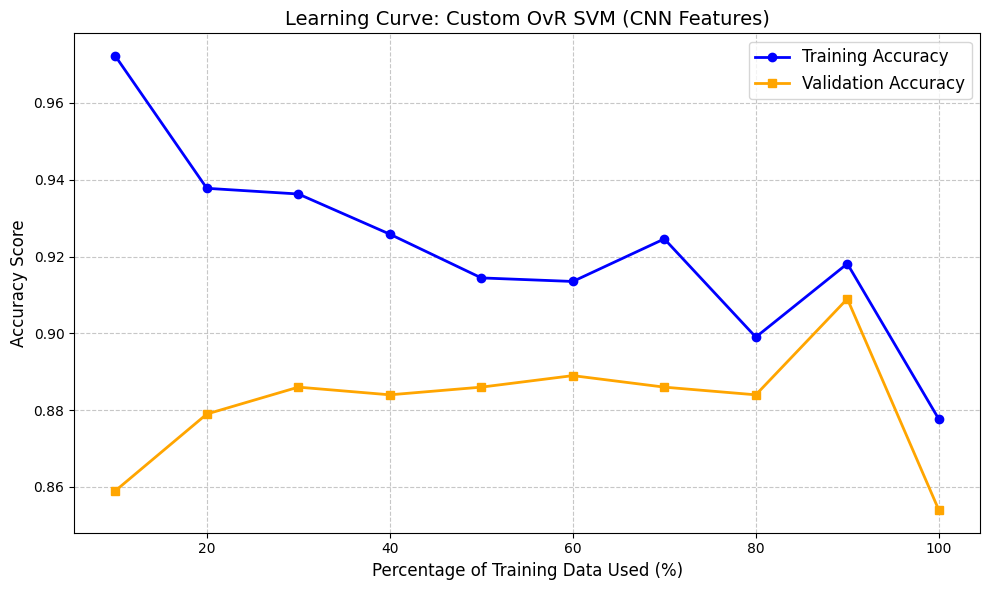

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from preprocessing2 import custom_accuracy_score,cnn


X_train_cnn, y_train_cnn, X_val_cnn, y_val_cnn, X_test_cnn, y_test_cnn = cnn(subset_limit=10000)

train_fractions = np.linspace(0.1, 1.0, 10)
train_scores = []
val_scores = []

total_train_samples = len(X_train_cnn)

print("Generating Data for Learning Curves...")
for fraction in train_fractions:
    subset_size = int(total_train_samples * fraction)
    print(f"Training on {subset_size} samples ({int(fraction*100)}%)...")
    
    X_subset = X_train_cnn[:subset_size]
    y_subset = y_train_cnn[:subset_size]
    
    # changable for each model
    curve_model = OneVsRestSVM(
        n_classes=10, 
        learning_rate=0.001, 
        lambda_param=0.0001, 
        n_iters=500
    )
    
    curve_model.fit(X_subset, y_subset)
    
    train_preds = curve_model.predict(X_subset)
    val_preds = curve_model.predict(X_val_cnn)
    
    train_scores.append(custom_accuracy_score(y_subset, train_preds))
    val_scores.append(custom_accuracy_score(y_val_cnn, val_preds))


plt.figure(figsize=(10, 6))
plt.plot(train_fractions * 100, train_scores, label="Training Accuracy", color="blue", marker="o", linewidth=2)
plt.plot(train_fractions * 100, val_scores, label="Validation Accuracy", color="orange", marker="s", linewidth=2)

plt.title("Learning Curve: Custom OvR SVM (CNN Features)", fontsize=14)
plt.xlabel("Percentage of Training Data Used (%)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()